# ⚙️ 01-梯度下降与迭代优化入门

> 目标：从**沿负梯度下降**这个最小动作出发，建立「步长（学习率）→ 收敛性 → 噪声」的直觉，并为后续
> 动量 / 自适应 / 二阶方法搭好对照系。

## §1 为什么从梯度下降讲起

所有优化器（SGD / Momentum / AdaGrad / Adam / 牛顿法）都共享同一个骨架：

$$w_{t+1} = w_t - \eta \, \text{（某种更新方向）}$$

区别只在**更新方向怎么构造**：

| 家族 | 更新方向 | 解决什么 | 代价 |
|------|----------|----------|------|
| SGD | $-g$ | 最基本 | 病态曲率震荡 / 无历史 / 一刀切 lr |
| 动量族 | 历史梯度 EMA $v$ | 震荡、平坦区 | 多一份状态 $v$ |
| 自适应 | $g/\sqrt{E[g^2]}$ | 逐参数步长（稀疏） | 多一份状态、泛化争议 |
| 二阶 | $H^{-1}g$ | 曲率自适应（牛顿） | $H$ 是 $n^2$ 存不下 |

**本节先只讲 SGD**：学习率怎么选、为什么过大发散、mini-batch 噪声从哪来。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 手写梯度下降（统一接口：step(w, g, t) -> w） ----------
def sgd_step(w, g, t, lr=0.1):
    return w - lr * g

def run_gd(f, grad_f, w0, steps, step_fn):
    w = w0.copy()
    hist = [w.copy()]
    for t in range(steps):
        g = grad_f(w)
        w = step_fn(w, g, t)
        hist.append(w.copy())
    return np.array(hist)

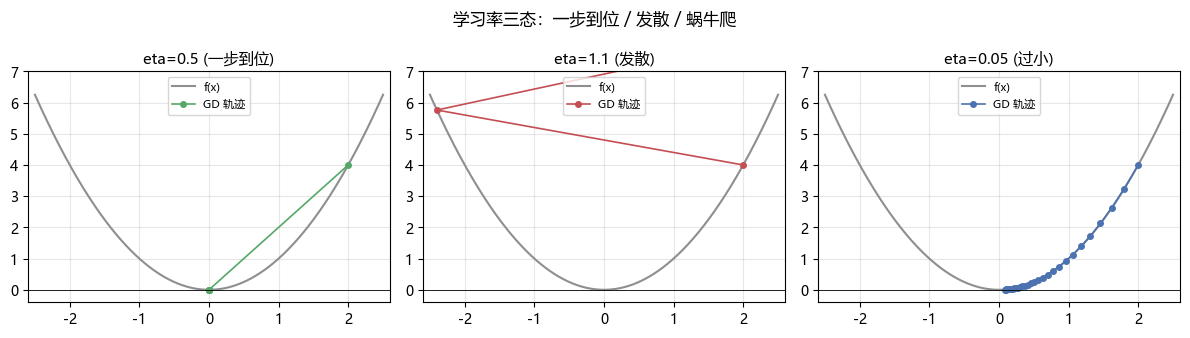

结论：eta > 1/a 时 |w| 逐次放大 -> 发散；eta 过小则收敛极慢


In [2]:
# ---------- 实验 1：一维凸函数 f(x)=x^2，最优步长可解析 ----------
# 解析最优步长：f(x)=0.5*a*x^2 -> 梯度=a*x -> 最优 eta=1/a（一步到位）
a = 2.0
f = lambda x: 0.5 * a * x**2
gf = lambda x: a * x

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
cases = [('eta=0.5 (一步到位)', 0.5, 5, '#55A868'),
         ('eta=1.1 (发散)', 1.1, 6, '#C44E52'),
         ('eta=0.05 (过小)', 0.05, 30, '#4C72B0')]
xs = np.linspace(-2.5, 2.5, 400)
for ax, (ttl, eta, steps, col) in zip(axes, cases):
    ax.plot(xs, f(xs), color='#8E8E93', lw=1.5, label='f(x)')
    hist = run_gd(f, gf, np.array([2.0]), steps, lambda w, g, t: w - eta * g)
    ax.plot(hist[:, 0], f(hist[:, 0]), 'o-', color=col, lw=1.2, ms=4, label='GD 轨迹')
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title(ttl, fontsize=11)
    ax.set_xlim(-2.6, 2.6); ax.set_ylim(-0.4, 7)
    ax.legend(fontsize=8, loc='upper center')
    ax.grid(alpha=0.3)
fig.suptitle('学习率三态：一步到位 / 发散 / 蜗牛爬', fontsize=12)
plt.tight_layout(); plt.show()
print('结论：eta > 1/a 时 |w| 逐次放大 -> 发散；eta 过小则收敛极慢')

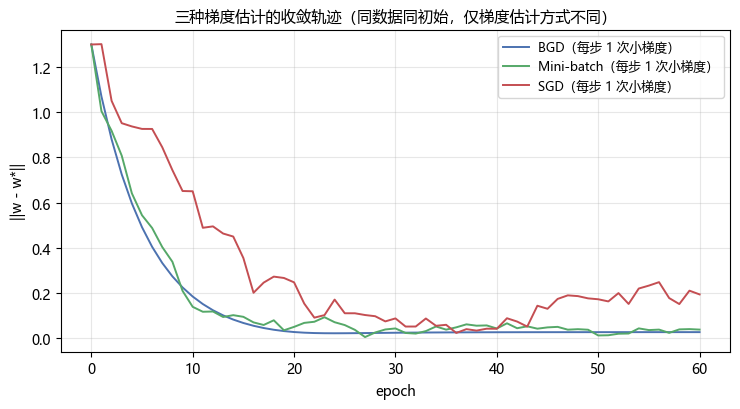

BGD 平滑单调；Mini-batch 有小噪声但快；SGD（单样本）噪声最大


In [3]:
# ---------- 实验 2：BGD / SGD / Mini-batch 的噪声来源 ----------
rng = np.random.default_rng(42)
N, D = 200, 2
X = rng.normal(size=(N, D)); X[:, 0] = 1.0  # 带偏置
w_true = np.array([0.5, -1.2])
y = X @ w_true + rng.normal(scale=0.3, size=N)

def loss_grad(w, idx):  # 在 idx 子集上算平均梯度
    r = X[idx] @ w - y[idx]
    return X[idx].T @ r / len(idx)

def train(mode, epochs=60, batch=16, lr=0.2):
    w = np.zeros(D); hist = [w.copy()]
    for e in range(epochs):
        if mode == 'BGD':
            g = loss_grad(w, np.arange(N))
        elif mode == 'SGD':
            g = loss_grad(w, np.array([rng.integers(N)]))
        else:
            idx = rng.integers(N, size=batch)
            g = loss_grad(w, idx)
        w = w - lr * g
        hist.append(w.copy())
    return np.array(hist)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for mode, col in [('BGD', '#4C72B0'), ('Mini-batch', '#55A868'), ('SGD', '#C44E52')]:
    hist = train(mode)
    dist = np.linalg.norm(hist - w_true, axis=1)
    ax.plot(dist, label=f'{mode}（每步 1 次小梯度）', color=col, lw=1.4)
ax.set_xlabel('epoch'); ax.set_ylabel('||w - w*||')
ax.set_title('三种梯度估计的收敛轨迹（同数据同初始，仅梯度估计方式不同）', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('BGD 平滑单调；Mini-batch 有小噪声但快；SGD（单样本）噪声最大')

## §2 公式与直觉（背诵）

- **更新**：$w \gets w - \eta g$，$g = \nabla_w \mathcal{L}$
- **一阶必要条件**：局部极小处 $\nabla f = 0$（凸函数时即全局）
- **凸函数**：$f(\theta x + (1-\theta)y) \le \theta f(x) + (1-\theta)f(y)$ → 梯度下降保证收敛
- **收敛速度**（强凸）：$f(w_t)-f^* \le O((1-\kappa^{-1})^t)$，条件数 $\kappa=\lambda_{max}/\lambda_{min}$ 越大越慢
- **为什么 mini-batch**：期望等于全梯度（无偏估计），方差随 batch 反比下降，单样本噪声大但算得快

## §3 常见 bug 与边界

- **lr 与特征尺度不匹配**：特征未归一化时，不同维度的梯度差几个数量级，一个 lr 顾此失彼 → 先标准化
- **lr 过大立即 NaN**：检查第一步 loss 是否为 inf
- **忘记梯度清零**：手写时每次迭代 `g = grad(w)` 而不是 `g += grad(w)`
- **停止条件**：`||g|| < tol` 或 loss 相对下降 < tol，不要只看绝对 loss

## §4 面试追问与扩展

1. **学习率怎么选**：先 0.01/0.001/0.1 三档粗扫，再观察 loss 曲线（震荡→降 lr；太缓→升）
2. **凸 vs 非凸**：神经网络非凸，收敛保证不适用；但局部极小通常足够好（高维时鞍点比局部极小更常见）
3. **为什么有时 loss 曲线毛刺**：mini-batch 噪声 → 用指数滑动平均平滑后观察趋势
4. **梯度下降与牛顿法关系**：牛顿法 = 梯度下降在「以 H 为度量的内积空间」里的最速下降（见 06 篇）

## §5 自测清单

- [ ] 手写 SGD 并在 $f=0.5x^2$ 上验证「$\eta=1/a$ 一步到位」
- [ ] 解释 lr 过大的发散机制（$|w_{t+1}| = |1-\eta a||w_t| > |w_t|$）
- [ ] 说明 BGD / SGD / Mini-batch 的噪声-速度权衡
- [ ] 默写强凸收敛速率 $O((1-\kappa^{-1})^t)$ 并说明条件数含义
- [ ] 能回答「loss 曲线震荡怎么办」

> 💡 下节预告：峡谷地形 + 历史动量（02 篇），自适应步长（03 篇）。